# "I, Justin Lee Cullop the First, did not use ChatGPT or any other AI/LLM to assist me on this assessment"

In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#read ins
gourds = pd.read_csv("./gourds.csv")
type_name = pd.read_csv("./type_name.csv")

In [3]:
#check out the first 5
gourds.head()

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk
0,2013,F,154.5 lb,1.0,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,154.5
1,2013,F,146.5 lb,2.0,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,146.5
2,2013,F,145.0 lb,3.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,145.0
3,2013,F,140.8 lb,4.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,140.8
4,2013,F,139.0 lb,5.5,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,139.0


In [4]:
#look at the weight column for weirdness
print(gourds['weight'])

0        154.5 lb
1        146.5 lb
2        145.0 lb
3        140.8 lb
4        139.0 lb
           ...   
28006    181.0 lb
28007    159.5 lb
28008    141.0 lb
28009    116.5 lb
28010     16.3 lb
Name: weight, Length: 28011, dtype: object


In [5]:
#check datatypes
gourds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28011 entries, 0 to 28010
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               28011 non-null  int64  
 1   type_id            28011 non-null  object 
 2   weight             28011 non-null  object 
 3   place              28011 non-null  float64
 4   grower_name        28011 non-null  object 
 5   city               25232 non-null  object 
 6   state_prov         28011 non-null  object 
 7   country            28011 non-null  object 
 8   gpc_site           28011 non-null  object 
 9   seed_mother        19468 non-null  object 
 10  pollinator_father  17704 non-null  object 
 11  ott                24854 non-null  float64
 12  est_weight         24854 non-null  float64
 13  variety            715 non-null    object 
 14  weight_bk          28011 non-null  float64
dtypes: float64(4), int64(1), object(10)
memory usage: 3.2+ MB


Text(0, 0.5, 'Count')

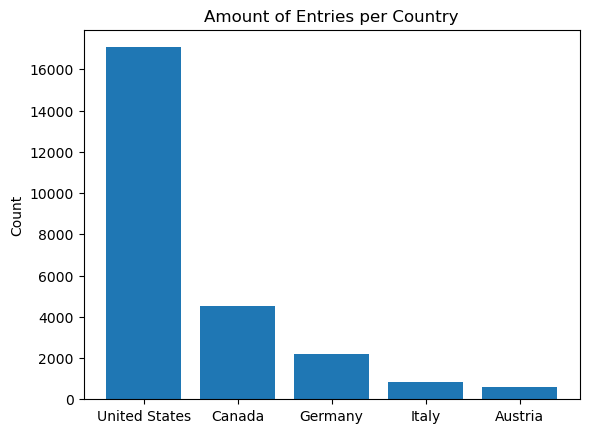

In [6]:
#get top 5 countries and plot
top5_countries = gourds['country'].value_counts().head()
# top5_countries
plt.bar(top5_countries.index, top5_countries.values)
plt.title("Amount of Entries per Country")
plt.ylabel("Count")

In [7]:
#convert weight to str to regex the "lb" or "in" away. Then convert column to float for maths
gourds['weight'] = gourds['weight'].astype(str)
gourds['weight'] = gourds['weight'].str.replace(r'(lb|in)$', '', regex=True)
gourds['weight'] = gourds['weight'].astype(float)

In [8]:
#check if i converted and regex'd the weight column right
gourds['weight'].max(), gourds['weight_bk'].max()

(2702.9, 2702.9)

## To the moon

Text(0, 0.5, 'Weight')

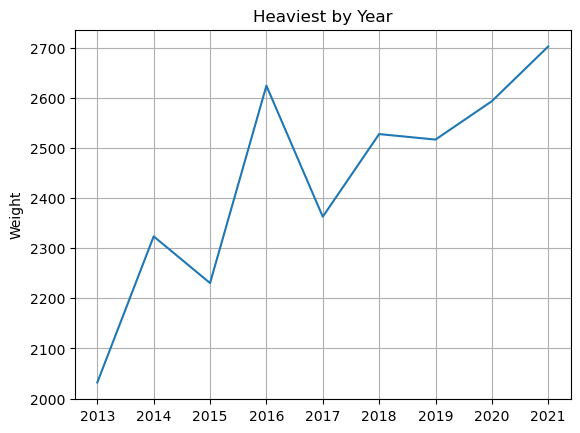

In [9]:
#get heaviest of each year and plot
heaviest_per_year = gourds.loc[gourds.groupby(gourds['year'])['weight'].idxmax()]
# heaviest_per_year

plt.plot(heaviest_per_year['year'], heaviest_per_year['weight'])
plt.title("Heaviest by Year")
plt.grid()
plt.ylabel("Weight")

In [10]:
#merge the gourd df with the lookup table type_id for gourd type names
gourds = pd.merge(gourds, type_name, on='type_id')

In [11]:
#make a way to get the mean for plotting
weight_by_type = gourds.groupby('type_name')['weight'].describe()

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Field Pumpkin'),
  Text(1, 0, 'Giant Pumpkin'),
  Text(2, 0, 'Giant Squash'),
  Text(3, 0, 'Giant Watermelon'),
  Text(4, 0, 'Long Gourd'),
  Text(5, 0, 'Tomato')])

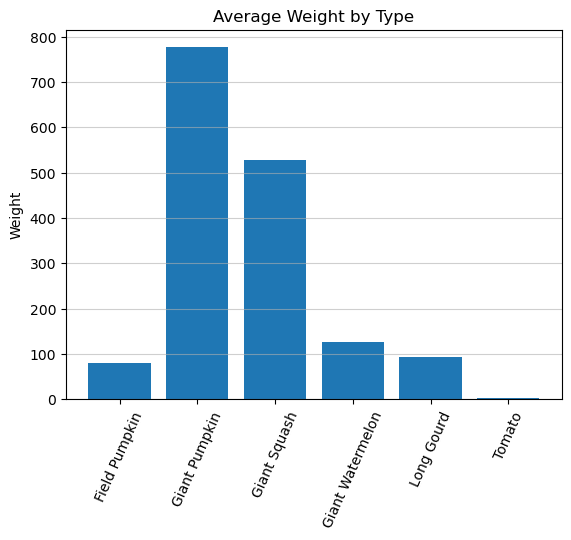

In [12]:
#plot each type of gourd and their avg weight
plt.bar(weight_by_type['mean'].index, weight_by_type['mean'].values)
plt.title("Average Weight by Type")
plt.ylabel("Weight")
plt.grid(axis='y', alpha=0.60)
plt.xticks(rotation=66)

In [13]:
#checking datatypes again cause im too lazy to scroll up
gourds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28011 entries, 0 to 28010
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               28011 non-null  int64  
 1   type_id            28011 non-null  object 
 2   weight             28011 non-null  float64
 3   place              28011 non-null  float64
 4   grower_name        28011 non-null  object 
 5   city               25232 non-null  object 
 6   state_prov         28011 non-null  object 
 7   country            28011 non-null  object 
 8   gpc_site           28011 non-null  object 
 9   seed_mother        19468 non-null  object 
 10  pollinator_father  17704 non-null  object 
 11  ott                24854 non-null  float64
 12  est_weight         24854 non-null  float64
 13  variety            715 non-null    object 
 14  weight_bk          28011 non-null  float64
 15  type_name          28011 non-null  object 
dtypes: float64(5), int64(1

In [14]:
#calculate and create new column for overestimatino of gourd weight
gourds['weight_error'] = (gourds['est_weight'] - gourds['weight']).clip(lower=0)
gourds2 = gourds.dropna(subset='est_weight', inplace=False)

In [15]:
#get the most outrageously overestimated weights
gourds2 = gourds2[gourds2['est_weight'] != 0.0]
gourds2.sort_values('weight_error', ascending=False)

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk,type_name,weight_error
20945,2019,P,316.0,1403.0,"Shenfish, Gary",Littleton,Colorado,United States,Fort Collins Nursery Weigh-off,2170 Daletes,1911 Urena,1132.0,11033.0,NaN,316.0,Giant Pumpkin,10717.0
13336,2017,P,1419.8,231.0,"Wuersching, Matthias",Einhausen,Hesse,Germany,Early Weigh-off Ludwigsburg,1781 Zywiec,900 Gansert,1072.0,9819.0,NaN,1419.8,Giant Pumpkin,8399.2
12385,2016,W,160.5,94.0,"Thompson, Travis",Florence,Ontario,Canada,Port Elgin Pumpkinfest (Sunday),193 Mitchell,193 Mitchell,0.0,1887.0,NaN,160.5,Giant Watermelon,1726.5
14910,2017,S,732.0,56.5,"Sikorski, John",Suring,Wisconsin,United States,Mishicot Pumpkin Fest,1196 Martin,selfed,496.0,2369.0,NaN,732.0,Giant Squash,1637.0
4185,2014,P,803.0,800.0,"Powell, Jesse",Oil Springs,Ontario,Canada,Port Elgin Pumpkinfest,411 Powell,411 Powell,517.0,2336.0,NaN,803.0,Giant Pumpkin,1533.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11741,2016,P,817.5,838.5,"Blair, Lloyd",Middlefield,Connecticut,United States,Woodstock Fair,809 Young,1625 Gantner,331.0,809.0,NaN,817.5,Giant Pumpkin,0.0
11742,2016,P,794.0,869.5,"Miller, Shane",Mertztown,Pennsylvania,United States,Grims Orchard and Family Farms,2020 Werner,self,318.0,720.0,NaN,794.0,Giant Pumpkin,0.0
11743,2016,P,729.5,957.0,"English, David",Emporium,Pennsylvania,United States,PGPGA Great Pumpkin Weigh-off,1676.5 Daletas,2009 Wallace,310.0,664.0,NaN,729.5,Giant Pumpkin,0.0
11745,2016,P,658.0,1052.0,"Wasielewski, Rick",Milton,Vermont,United States,Vermont Growers Weigh-off,1332 Companion,1778.5 Daletas,304.0,630.0,NaN,658.0,Giant Pumpkin,0.0


## maybe some invalid inputs, maybe people are silly. Overall people are pretty close on estimation

Text(0.5, 0, 'Actual Weight')

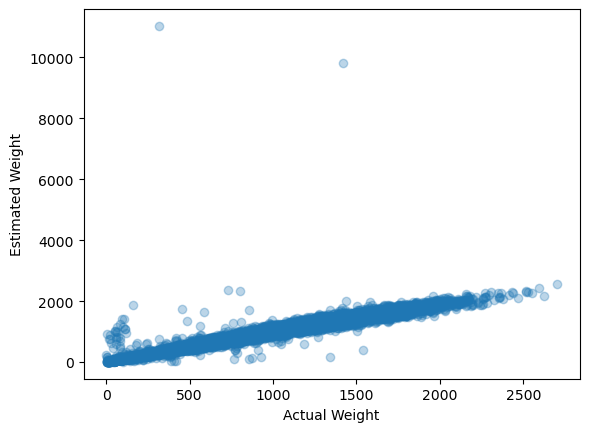

In [16]:
#plot the relationship between estimated weights and their actual weights
plt.scatter(gourds2['weight'], gourds2['est_weight'], alpha=0.3)
plt.ylabel('Estimated Weight')
plt.xlabel('Actual Weight')

In [17]:
#return only rows that place 10th or better
top10_all = gourds[gourds['place'] <= 10]
top10_all

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk,type_name,weight_error
0,2013,F,154.5,1.0,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,154.5,Field Pumpkin,0.0
1,2013,F,146.5,2.0,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,146.5,Field Pumpkin,4.5
2,2013,F,145.0,3.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,145.0,Field Pumpkin,0.0
3,2013,F,140.8,4.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,140.8,Field Pumpkin,10.2
4,2013,F,139.0,5.5,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,139.0,Field Pumpkin,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27763,2021,W,289.5,6.0,"Vial, Andrew",Liberty,North Carolina,United States,Yadkin Valley Pumpkin Weigh-off,341.5 Vial,316 Edwards,220.0,291.0,NaN,289.5,Giant Watermelon,1.5
27764,2021,W,288.0,7.0,"Mudd, Frank",Vine Grove,Kentucky,United States,Roberts Family Farms,305 Mudd,selfed,222.0,298.0,NaN,288.0,Giant Watermelon,10.0
27765,2021,W,284.0,8.0,"Dawson, Todd",garner,North Carolina,United States,Tennessee Valley Fair,302 Kent,Self,214.0,270.0,NaN,284.0,Giant Watermelon,0.0
27766,2021,W,270.0,9.0,"Mudd, Framk",Vine Grove,Kentucky,United States,Allardt Pumpkin Festival,305 Mudd,Selfed,210.0,254.0,NaN,270.0,Giant Watermelon,0.0


In [18]:
#get a table of who has the most top 10's  
gourd_type_amount = top10_all.groupby('grower_name')['type_id'].nunique().sort_values(ascending=False)
gourd_type_amount

grower_name
Martin, Margaret & Glen    4
Jutras, Joe                3
Ansems, Fred               3
Tobeck, Cindy              3
Werner, Quinn              3
                          ..
Zappa, Lee and Derrik      1
Zywiec, Lorelee            1
kent, Chris                1
team, Willemijns           1
vial, Andrew               1
Name: type_id, Length: 247, dtype: int64

In [19]:
#sanity check
top10_all[top10_all['grower_name'] == "Harnica, John"]

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk,type_name,weight_error
3220,2014,L,132.00,3.0,"Harnica, John",Dundee,Michigan,United States,Harnica Farms Great Pumpkin Weigh-off,139 Ansem,120 Kline,0.0,0.0,NaN,132.00,Long Gourd,0.0
6388,2015,L,133.50,9.0,"Harnica, John",Dundee,Michigan,United States,Harnica Farms Great Pumpkin Weigh-off,137.5 Ansems,139.25 Ansems,0.0,0.0,NaN,133.50,Long Gourd,0.0
6389,2015,L,130.50,10.0,"Harnica, John",Dundee,Michigan,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,NaN,NaN,0.0,0.0,NaN,130.50,Long Gourd,0.0
11767,2016,S,1208.50,6.0,"Harnica, John",Dundee,Michigan,United States,Harnica Farms Great Pumpkin Weigh-off,1069 Harnica*,Self,379.0,1179.0,NaN,1208.50,Giant Squash,0.0
12912,2017,F,153.50,7.0,"Harnica, John",Dundee,Michigan,United States,Harnica Farms Great Pumpkin Weigh-off,conestoga giant,NaN,191.0,144.0,NaN,153.50,Field Pumpkin,0.0
12920,2017,L,135.13,8.0,"Harnica, John",Dundee,Michigan,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,141 Kline,127 Harnica,0.0,0.0,NaN,135.13,Long Gourd,0.0
19333,2019,L,137.50,9.5,"Harnica, John",Dundee,Michigan,United States,Dundees Pumpkin Palooza,149.25 Checkon,Sibb,0.0,0.0,NaN,137.50,Long Gourd,0.0
22649,2020,L,135.10,5.0,"Harnica, John",Dundee,Michigan,United States,Dundees Pumpkin Palooza,155.7 Lazik,open,0.0,0.0,NaN,135.10,Long Gourd,0.0
25541,2021,L,137.38,8.0,"Harnica, John",Dundee,Michigan,United States,Dundees Pumpkin Palooza,124.5 Harnica,self,0.0,0.0,NaN,137.38,Long Gourd,0.0
27235,2021,S,1464.00,8.0,"Harnica, John",Dundee,Michigan,United States,Dundees Pumpkin Palooza,1109 Jutras,self,410.0,1506.0,NaN,1464.00,Giant Squash,42.0


In [20]:
#store the toppest of top10 grower and how many categories
#who needs a sanity check amirite :P
top_grower = gourd_type_amount.idxmax()
type_amount = gourd_type_amount.max()
print(f"{top_grower} has top 10 in {type_amount} categories")

Martin, Margaret & Glen has top 10 in 4 categories


In [21]:
#store what place twas their best and display stuff
grower_best = int(gourds[gourds['grower_name'] == top_grower]['place'].min())
print(f"{top_grower} best is {grower_best}nd palce")

Martin, Margaret & Glen best is 2nd palce


In [22]:
# REDACTED
# gourds[gourds['grower_name'].str.contains('Martin,')]['grower_name'].unique()

In [23]:
#convert column to lowercase cause people aren't consistent
#get counts of seed_mother and sum all that are over 100
#then display 
gourds['seed_mother'] = gourds['seed_mother'].str.lower()
seed_mother_amount = gourds['seed_mother'].value_counts()
(seed_mother_amount >= 100).sum()
seed_mother_amount[seed_mother_amount >= 100]

seed_mother
unknown          542
2145 mcmullen    131
2009 wallace     108
1985 miller      101
Name: count, dtype: int64

In [24]:
#convert column to lowercase cause people aren't consistent
#get counts of pollinator_father and sum all that are over 100
#then display 
gourds['pollinator_father'] = gourds['pollinator_father'].str.lower()
pollinator_father_amount = gourds['pollinator_father'].value_counts()
(pollinator_father_amount >= 100).sum()
pollinator_father_amount[pollinator_father_amount >= 100]

pollinator_father
open             4782
self             3955
unknown           214
2009 wallace      156
sib               151
2145 mcmullen     129
Name: count, dtype: int64

In [25]:
#when mama and dada love each other very much they merge on the horizontal axis=1 (lol) and keys=label our columns
offspring = pd.concat([seed_mother_amount[seed_mother_amount >= 100], pollinator_father_amount[pollinator_father_amount >= 100]],
    axis=1,
    keys=['seed_mother', 'pollinator_father']
)

offspring

,seed_mother,pollinator_father
unknown,542.0,214.0
2145 mcmullen,131.0,129.0
2009 wallace,108.0,156.0
1985 miller,101.0,NaN
open,NaN,4782.0
self,NaN,3955.0
sib,NaN,151.0


In [26]:
#creating new column to hold the addition of mama and dada gourds
offspring['offspring'] = (offspring['seed_mother'] + offspring['pollinator_father'])

In [27]:
#Well, they all look a lil funny when they first come out
offspring

,seed_mother,pollinator_father,offspring
unknown,542.0,214.0,756.0
2145 mcmullen,131.0,129.0,260.0
2009 wallace,108.0,156.0,264.0
1985 miller,101.0,NaN,NaN
open,NaN,4782.0,NaN
self,NaN,3955.0,NaN
sib,NaN,151.0,NaN
